In [2]:
import pandas as pd
import numpy as np
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.optim import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt

## 1. Setup
Speed/accuracy knobs for training (subset, minibatch size, steps, predictive samples).

In [3]:
TRAIN_SUBSET = 50000     # set None to use full training set (slow)
BATCH_SIZE = 2048        # mini-batch size
NUM_STEPS = 2000         # fewer steps usually enough with minibatches
NUM_SAMPLES = 300        # posterior predictive samples (faster than 1000)

## 2. Load data (and convert Fare to USD)
We load the cleaned dataset, keep the selected features, drop missing values, and convert Fare from INR to USD.

In [4]:
df = pd.read_csv("data/Cleaned_dataset.csv")

target = "Fare"

categorical_cols = [
    "Journey_day", "Airline", "Source", "Departure", "Total_stops", "Arrival", "Destination"
]
numeric_cols = [
    "Duration_in_hours", "Days_left"
]

df = df[categorical_cols + numeric_cols + [target]].dropna().copy()

# INR -> USD
df[target] = df[target].astype(float) * 0.01066

## 3. Train/test split (no leakage)
Split before preprocessing so encoders/scalers are fit on train only.

In [5]:
X = df[categorical_cols + numeric_cols]
y_usd = df[target].values.astype("float32")

X_train_df, X_test_df, y_train_usd, y_test_usd = train_test_split(
    X, y_usd, test_size=0.2, random_state=42
)

# Optional: subset the training data for speed (baseline)
if TRAIN_SUBSET is not None and TRAIN_SUBSET < len(X_train_df):
    idx = np.random.RandomState(42).choice(len(X_train_df), size=TRAIN_SUBSET, replace=False)
    X_train_df = X_train_df.iloc[idx].copy()
    y_train_usd = y_train_usd[idx]

## 4. Target transform
Apply log1p to reduce skew, then standardize using train mean/std.

In [9]:
# Log-transform fares (USD)
y_train_log = np.log1p(y_train_usd).astype("float32")
y_test_log = np.log1p(y_test_usd).astype("float32")

# Standardize target (train stats only)
y_mean = float(y_train_log.mean())
y_std = float(y_train_log.std())
if y_std == 0 or np.isnan(y_std):
    y_std = 1.0

y_train = ((y_train_log - y_mean) / y_std).astype("float32")
y_test = ((y_test_log - y_mean) / y_std).astype("float32")


try:
    ohe = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", ohe, categorical_cols),
    ],
    remainder="drop",
)

X_train = preprocess.fit_transform(X_train_df).astype("float32")
X_test = preprocess.transform(X_test_df).astype("float32")

cat_feature_names = preprocess.named_transformers_["cat"].get_feature_names_out(categorical_cols)
feature_names = numeric_cols + list(cat_feature_names)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t = torch.tensor(X_test)
y_test_t = torch.tensor(y_test)

pyro.clear_param_store()

n_features = X_train_t.shape[1]

## 5. Bayesian linear regression in Pyro (SVI)
Define the probabilistic model + variational guide and train with minibatch SVI.

Step 0 | Loss: 140053.91
Step 200 | Loss: 133139.21
Step 400 | Loss: 127476.20
Step 600 | Loss: 520769.03
Step 800 | Loss: 1820606.72
Step 1000 | Loss: 1286714.36
Step 1200 | Loss: 22470973.67
Step 1400 | Loss: 486798.63
Step 1600 | Loss: 9668810.86
Step 1800 | Loss: 101456.63


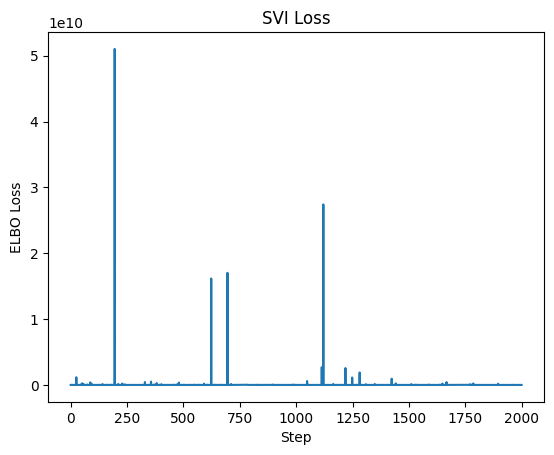

In [ ]:
def model(X, y=None):
    n_obs, n_features_local = X.shape

    alpha = pyro.sample("alpha", dist.Normal(0.0, 5.0))
    beta = pyro.sample(
        "beta",
        dist.Normal(torch.zeros(n_features_local), torch.ones(n_features_local)).to_event(1),
    )
    sigma = pyro.sample("sigma", dist.HalfNormal(1.0))

    with pyro.plate("data", n_obs, subsample_size=min(BATCH_SIZE, n_obs)) as idx:
        X_b = X[idx]
        mu = alpha + X_b @ beta
        pyro.sample("obs", dist.Normal(mu, sigma), obs=None if y is None else y[idx])


def guide(X, y=None):
    n_features_local = X.shape[1]

    alpha_loc = pyro.param("alpha_loc", torch.tensor(0.0))
    alpha_scale = pyro.param("alpha_scale", torch.tensor(1.0), constraint=dist.constraints.positive)

    beta_loc = pyro.param("beta_loc", torch.zeros(n_features_local))
    beta_scale = pyro.param("beta_scale", torch.ones(n_features_local), constraint=dist.constraints.positive)

    sigma_scale = pyro.param("sigma_scale", torch.tensor(1.0), constraint=dist.constraints.positive)

    pyro.sample("alpha", dist.Normal(alpha_loc, alpha_scale))
    pyro.sample("beta", dist.Normal(beta_loc, beta_scale).to_event(1))
    pyro.sample("sigma", dist.HalfNormal(sigma_scale))


optimizer = Adam({"lr": 0.01})  # minibatches usually tolerate a bit higher lr
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

losses = []
for step in range(NUM_STEPS):
    loss = svi.step(X_train_t, y_train_t)
    losses.append(loss)

    if step % 200 == 0:
        print(f"Step {step} | Loss: {loss:.2f}")

plt.plot(losses)
plt.title("SVI Loss")
plt.xlabel("Step")
plt.ylabel("ELBO Loss")
plt.show()

## 6. Posterior predictive evaluation
Generate predictive samples on the full test set and report MAE/RMSE in USD + uncertainty intervals.

MAE (USD): 160.77874755859375
RMSE (USD): 222.4686073359565


,feature,posterior_mean_beta
35,Destination_Mumbai,0.230434
4,Journey_day_Sunday,0.216587
28,Arrival_After 6 PM,0.166944
6,Journey_day_Tuesday,0.154038
20,Source_Kolkata,0.119869
17,Source_Chennai,0.097933
18,Source_Delhi,0.094256
21,Source_Mumbai,0.088213
19,Source_Hyderabad,0.071397
22,Departure_6 AM - 12 PM,0.054885


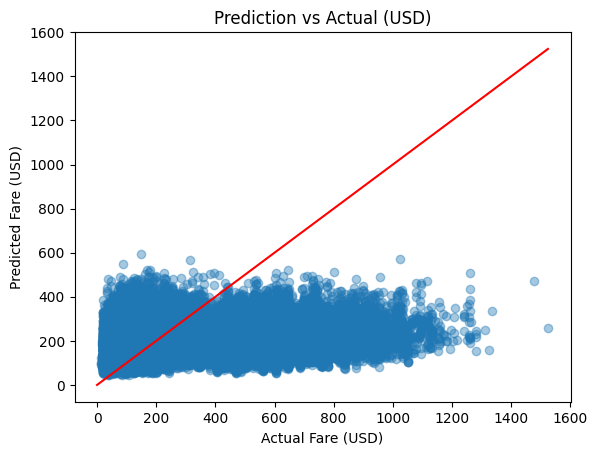

In [ ]:
def model_full(X, y=None):
    n_obs, n_features_local = X.shape

    alpha = pyro.sample("alpha", dist.Normal(0.0, 5.0))
    beta = pyro.sample(
        "beta",
        dist.Normal(torch.zeros(n_features_local), torch.ones(n_features_local)).to_event(1),
    )
    sigma = pyro.sample("sigma", dist.HalfNormal(1.0))

    mu = alpha + X @ beta
    with pyro.plate("data", n_obs):
        pyro.sample("obs", dist.Normal(mu, sigma), obs=y)

predictive = Predictive(
    model_full,
    guide=guide,
    num_samples=NUM_SAMPLES,
    return_sites=("obs",),
)

posterior_samples = predictive(X_test_t, None)
y_pred_scaled_samples = posterior_samples["obs"].detach().cpu().numpy()

# Inverse scaling back to log(USD)
y_pred_log_samples = y_pred_scaled_samples * y_std + y_mean
y_pred_log_mean = y_pred_log_samples.mean(axis=0)

# Back to USD
y_pred_usd = np.expm1(y_pred_log_mean)

mae = mean_absolute_error(y_test_usd, y_pred_usd)
rmse = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))

print("MAE (USD):", mae)
print("RMSE (USD):", rmse)

# Uncertainty (95% interval)
lower = np.expm1(np.percentile(y_pred_log_samples, 2.5, axis=0))
upper = np.expm1(np.percentile(y_pred_log_samples, 97.5, axis=0))

results = pd.DataFrame({
    "actual_fare_usd": y_test_usd,
    "predicted_fare_usd": y_pred_usd,
    "lower_95_usd": lower,
    "upper_95_usd": upper
})


# Coefficients
beta_mean = pyro.param("beta_loc").detach().cpu().numpy()

coef_df = pd.DataFrame({
    "feature": feature_names,
    "posterior_mean_beta": beta_mean
}).sort_values("posterior_mean_beta", ascending=False)

display(coef_df.head(20))


# Plot: predicted vs actual (USD)
plt.scatter(results["actual_fare_usd"], results["predicted_fare_usd"], alpha=0.4)
m = results["actual_fare_usd"].max()
plt.plot([0, m], [0, m], color="red")
plt.xlabel("Actual Fare (USD)")
plt.ylabel("Predicted Fare (USD)")
plt.title("Prediction vs Actual (USD)")
plt.show()